# AR Modeling from ACF/PACF to Forecasting

### Importing Required Libraries

In [4]:
from typing import Any, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm, uniform
from scipy.optimize import minimize
from statsmodels.tsa.stattools import acf, pacf

### Part I: Auto-Correlation Function

In [5]:
def acf_impl(x_t: np.ndarray, n_lags: int) -> np.ndarray:
    """Calculate the estimated ACF function for a time series."""
    
    x = np.asarray(x_t, dtype=float).ravel()
    T = x.shape[0]
    
    if T < 2:
        raise ValueError("x_t must have length >= 2.")
    if n_lags < 0:
        raise ValueError("n_lags must be >= 0.")

    n_lags = min(n_lags, T - 1)
    x = x - x.mean()
    gamma0 = (x @ x) / T

    if gamma0 == 0:
        # constant series
        acf = np.zeros(n_lags + 1, dtype=float)
        acf[0] = 1.0
        return acf
        
    acf = np.empty(n_lags + 1, dtype=float)
    acf[0] = 1.0
    for h in range(1, n_lags + 1):
        acf[h] = np.dot(x[:T - h], x[h:]) / (T * gamma0)   # biased estimator

    return acf

Now we can run our function on white noise and make sure we get the right result.

$$
w_t \sim N(0,\sigma^2)
$$

**To do this we'll will have to:**

1. Generate white noise with $\sigma = 1$ and sample size $n = 500$ from the process above.
2. Calculate the sample ACF up to lag $= 20$.
3. Calculate the analytical ACF.

In [6]:
n_lags = 20
mean = 0.0
std = 1.0
n = 500

# 1 - Generate realizations from the white noise process.
w_t = np.random.normal(mean, std, n)

# 2 - Calculate the sample ACF with lag of 20 
acf_estim_yours = acf_impl(w_t, n_lags)

# 3 - Calculate the analytical ACF. 
acf_analytical = np.zeros(n_lags + 1, dtype=float)
acf_analytical[0] = 1.0

# Let's check the implementation
acf_estim_statsm = acf(w_t, nlags=n_lags)
np.testing.assert_array_almost_equal(acf_estim_statsm, acf_estim_yours)

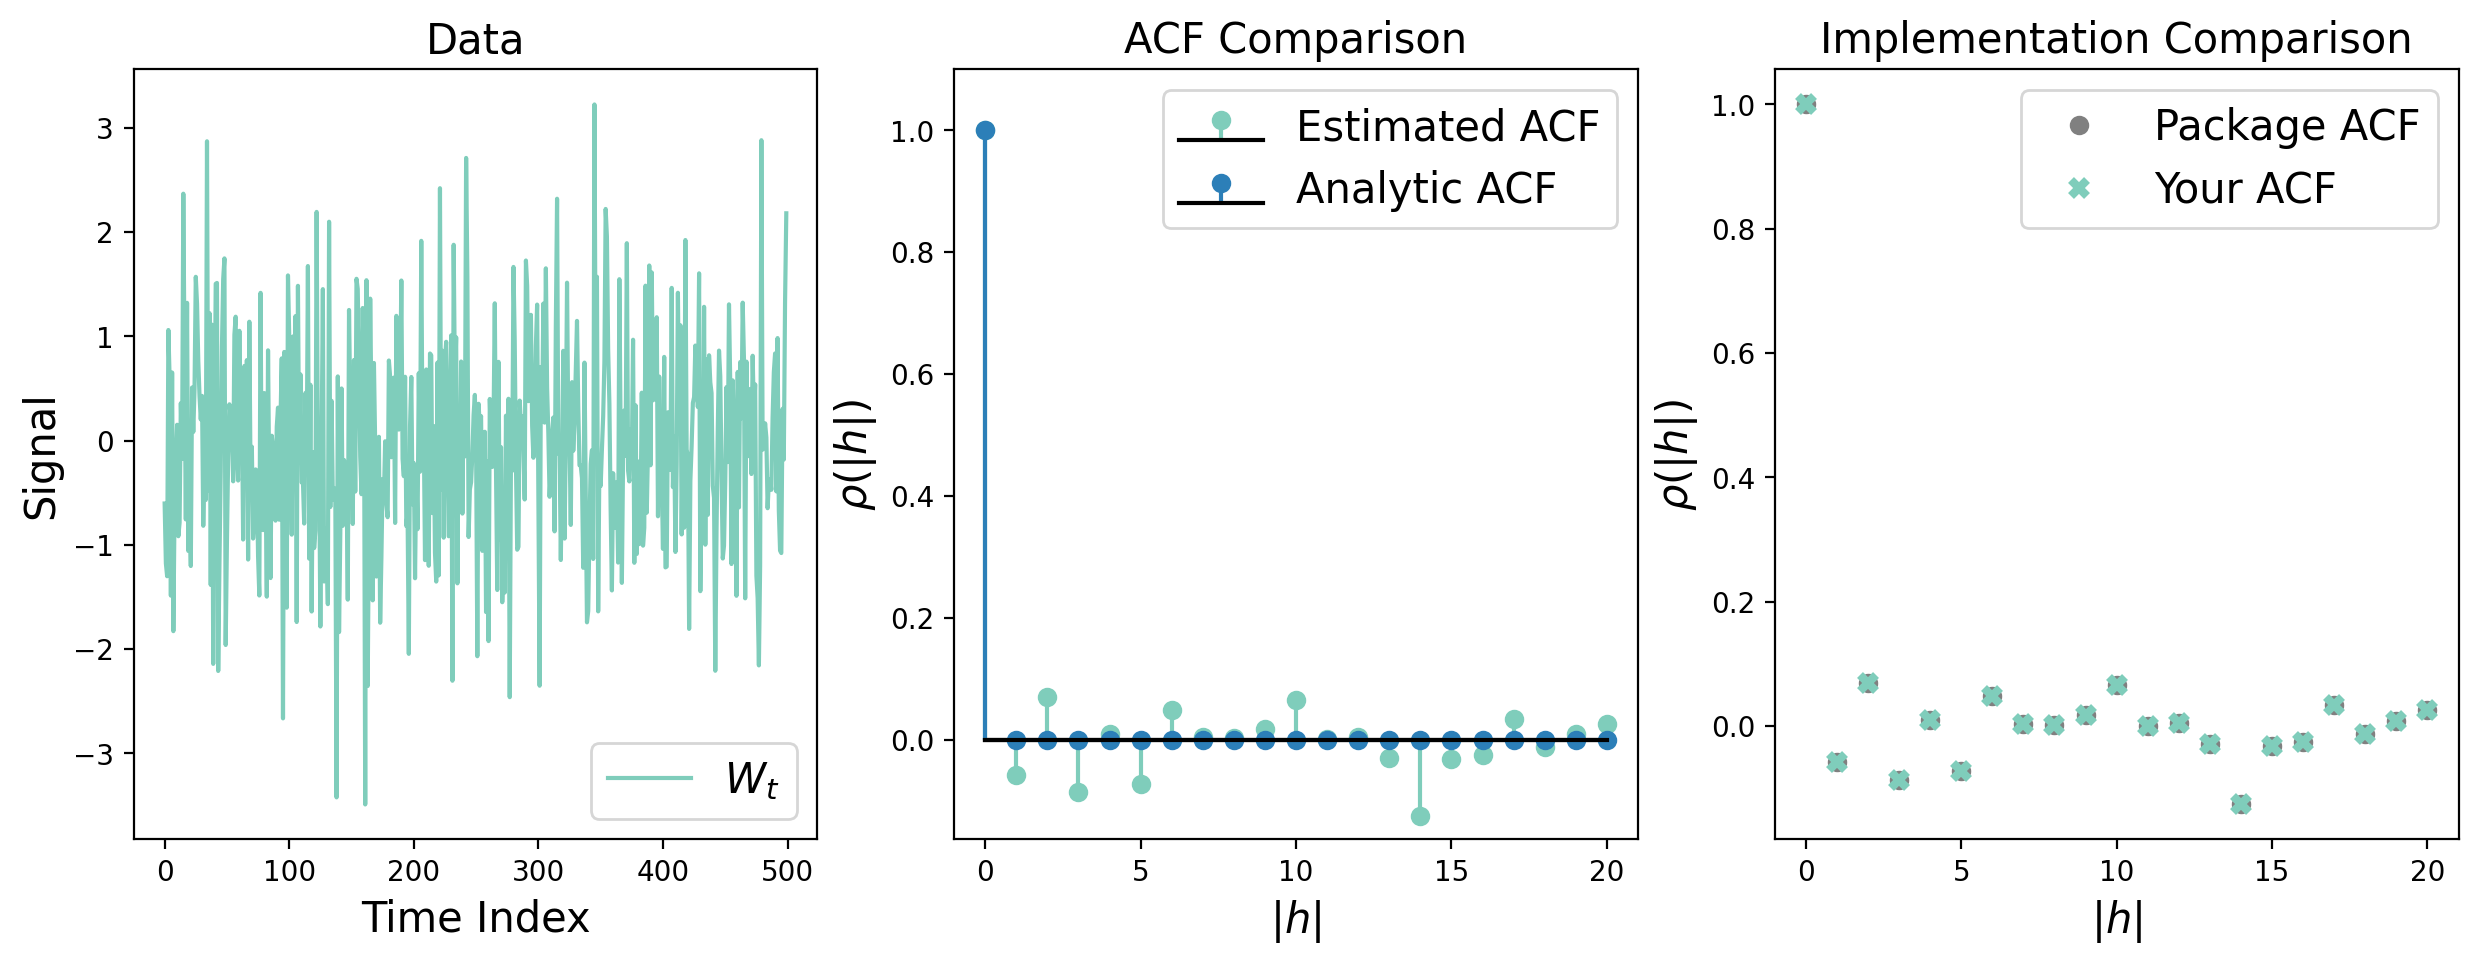

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), dpi=200)
fontsize = 15
colors = ['#7fcdbb', '#2c7fb8']

# Plot our white noise.
ax1.plot(w_t, label=r'$W_t$', color=colors[0])
ax1.set_title('Data', fontsize=fontsize)
ax1.set_xlabel('Time Index', fontsize=fontsize)
ax1.set_ylabel('Signal', fontsize=fontsize)
ax1.legend(fontsize=fontsize)

# Plot comparison between analytic and estiamted.
ax2.stem(acf_estim_yours, linefmt=colors[0], markerfmt=colors[0], basefmt='k', label='Estimated ACF')
ax2.stem(acf_analytical, linefmt=colors[1], markerfmt=colors[1], basefmt='k', label='Analytic ACF')
ax2.set_ylim([1.3*min(acf_estim_yours), 1.1*(std**2)])
ax2.set_title('ACF Comparison', fontsize=fontsize)
ax2.set_xlabel(r'$|h|$', fontsize=fontsize)
ax2.set_ylabel(r'$\rho(|h|)$', fontsize=fontsize)
ax2.legend(fontsize=fontsize)

# Plot comparison between our estimate and the library estimate.
acf_val_impl = acf_impl(x_t=w_t, n_lags=n_lags)
ax3.plot(acf_estim_statsm, 'o', color='grey', label='Package ACF')
ax3.plot(acf_estim_yours, 'x', ms=6, mew=3, color=colors[0], label='Your ACF')
ax3.legend(fontsize=fontsize)
ax3.set_xlabel(r'$|h|$', fontsize=fontsize)
ax3.set_ylabel(r'$\rho(|h|)$', fontsize=fontsize)
ax3.set_title('Implementation Comparison', fontsize=fontsize)

plt.show()

Now imagine that instead of having a time series with 500 data points, we only had 50. How would you expect the estimated ACF to change?

**To do this we'll will have to:**

1. Generate white noise with $\sigma = 1$ and sample size $n = 50$ from the process above.
2. Calculate the sample ACF up to lag $= 20$.

In [11]:
n_lags = 20
mean = 0.0
std = 1.0
n = 50

# 1 - Generate realizations from the white noise process.
w_t_short = np.random.normal(mean, std, n)

# 2 - Calculate the sample ACF with lag of 20 
acf_estim_yours = acf_impl(w_t, n_lags)

# Let's check the implementation
acf_estim_statsm = acf(w_t, nlags=n_lags)
np.testing.assert_array_almost_equal(acf_estim_statsm, acf_estim_yours)

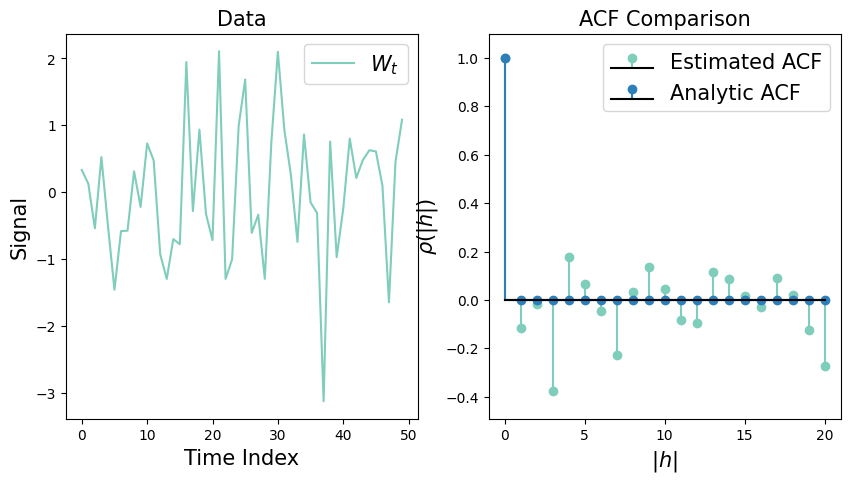

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), dpi=100)
fontsize = 15
colors = ['#7fcdbb', '#2c7fb8']

# Plot our white noise.
ax1.plot(w_t_short, label=r'$W_t$', color=colors[0])
ax1.set_title('Data', fontsize=fontsize)
ax1.set_xlabel('Time Index', fontsize=fontsize)
ax1.set_ylabel('Signal', fontsize=fontsize)
ax1.legend(fontsize=fontsize)

# Plot comparison between analytic and estimated.
ax2.stem(acf_estim_yours, linefmt=colors[0], markerfmt=colors[0], basefmt='k', label='Estimated ACF')
ax2.stem(acf_analytical, linefmt=colors[1], markerfmt=colors[1], basefmt='k', label='Analytic ACF')
ax2.set_ylim([1.3*min(acf_estim_yours), 1.1])
ax2.set_title('ACF Comparison', fontsize=fontsize)
ax2.set_xlabel(r'$|h|$', fontsize=fontsize)
ax2.set_ylabel(r'$\rho(|h|)$', fontsize=fontsize)
ax2.legend(fontsize=fontsize)

plt.show()

### Part II: Auto-Correlation Function for AR(2)

The auto-correlation function of white noise is somewhat trivial; let's consider a more interesting process. Take an AR(2) process of the form:

$$
X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + W_t
$$

We can generate the same plots as before, but we will have to:

1. Generate samples for the AR(2) process. Assume the boundary condition that $X_0 = W_0$ and $X_1 = \phi_1 X_0 + W_1$. Also assume that $W_t$ is the same white noise process from above, $\phi_1 = 0.5$, and $\phi_2 = 0.2$. Create a sample size of $n = 500$.
2. Calculate the sample ACF up to lag $= 20$.

In [19]:
def ar_two(phi_one: float, phi_two: float, n_samps: int, sigma_w: Optional[float] = 1) -> np.ndarray:
    """Generate samples from an AR(2) process.

    Args:
        phi_one: First constant of the AR(2) process.
        phi_two: Second constant of the AR(2) process.
        n_samps: Number of samples to draw.

    Returns:
        Samples from the AR(2) process.

    Notes:
        Assumes X_0 = W_0, X_1 = phi_1 X_0 + W_1, and that W_t ~ N(0,1)
    """
    if n_samps < 2:
        raise ValueError("n_samps must be >= 2")
    
    W = np.random.normal(0.0, sigma_w, n_samps)
    x = np.zeros(n_samps, dtype=float)

    x[0] = W[0]
    x[1] = (phi_one * x[0]) + W[1]
    
    for i in range(2, n_samps):
        x[i] = (phi_one * x[i - 1]) + (phi_two * x[i - 2]) + W[i]

    return x

In [20]:
# Let's check the above function against a reference value:
np.random.seed(1)
test_implementation = ar_two(0.1, 0.1, 5)
reference_value = np.array([1.62434536, -0.44932188, -0.4106694, -1.15896775, 0.70844391])
np.testing.assert_array_almost_equal(test_implementation, reference_value, decimal=5)

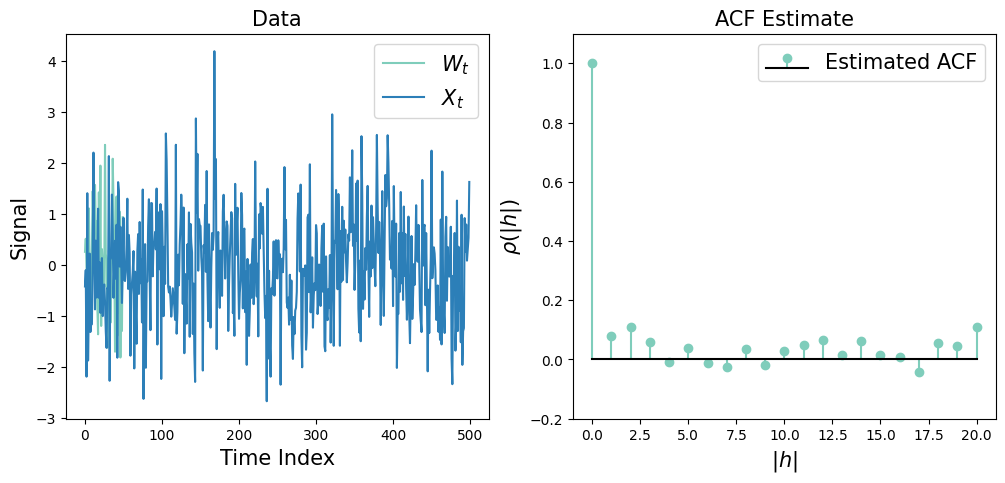

In [21]:
n_lags = 20
np.random.seed(2)

# 1. Generate the samples using the function above.
x_t = ar_two(phi_one=0.1, phi_two=0.1, n_samps=500, sigma_w=1.0)

# 2. Calculate the sample ACF.
acf_estim_yours = acf_impl(x_t, n_lags)

# Now sthe plotting functions visualize the different quantities.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
fontsize = 15
colors = ['#7fcdbb', '#2c7fb8']

# Plot the white noise.
ax1.plot(w_t, label=r'$W_t$', color=colors[0]) # This is not the same white noise realization as was used for X_t, it's just here for illustration.
ax1.plot(x_t, label=r'$X_t$', color=colors[1])
ax1.set_title('Data', fontsize=fontsize)
ax1.set_xlabel('Time Index', fontsize=fontsize)
ax1.set_ylabel('Signal', fontsize=fontsize)
ax1.legend(fontsize=fontsize)

# Plot comparison between analytic and estiamted.
ax2.stem(acf_estim_yours, linefmt=colors[0], markerfmt=colors[0], basefmt='k', label='Estimated ACF')
ax2.set_ylim([-0.2, 1.1])
ax2.set_title('ACF Estimate', fontsize=fontsize)
ax2.set_xlabel(r'$|h|$', fontsize=fontsize)
ax2.set_ylabel(r'$\rho(|h|)$', fontsize=fontsize)
ax2.legend(fontsize=fontsize)

plt.show()

### Part III: Partial Auto-Correlation Function for AR(2)

It's clear that the auto-correlation function is more complex for AR(2) than for white noise. So, it would be hard for us to identify this as an AR(2) process from the auto-correlation function alone. We can instead use the partial auto-correlation function to achieve this.

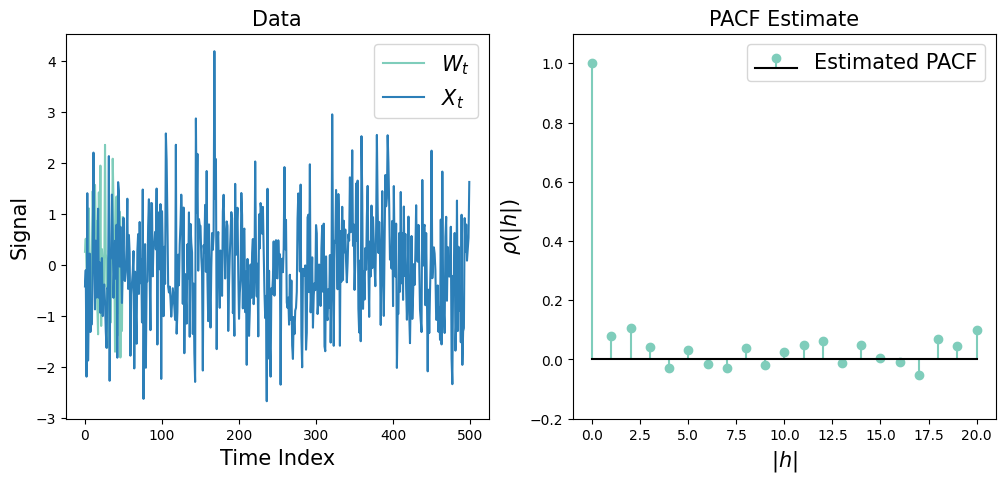

In [22]:
n_lags = 20

pacf_estim = pacf(x_t, n_lags)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
fontsize = 15
colors = ['#7fcdbb', '#2c7fb8']

# Plot our white noise.
ax1.plot(w_t, label=r'$W_t$', color=colors[0]) # This is not the same white noise realization as was used for X_t, it's just here for illustration.
ax1.plot(x_t, label=r'$X_t$', color=colors[1])
ax1.set_title('Data', fontsize=fontsize)
ax1.set_xlabel('Time Index', fontsize=fontsize)
ax1.set_ylabel('Signal', fontsize=fontsize)
ax1.legend(fontsize=fontsize)

# Plot comparison between analytic and estiamted.
ax2.stem(pacf_estim, linefmt=colors[0], markerfmt=colors[0], basefmt='k', label='Estimated PACF')
ax2.set_ylim([-0.2, 1.1])
ax2.set_title('PACF Estimate', fontsize=fontsize)
ax2.set_xlabel(r'$|h|$', fontsize=fontsize)
ax2.set_ylabel(r'$\rho(|h|)$', fontsize=fontsize)
ax2.legend(fontsize=fontsize)

plt.show()